In [4]:
from models.ast_autoencoder import ASTAutoencoder
import torch

model = ASTAutoencoder(
    hidden_dim=128,
    encoder_layers=3,
    max_decode_steps=100
)

model.to(torch.device("mps"))

file = "/Users/alexey/code/personal/HRM/training_artifacts/fixed_loss_v3_experiment_2k_2/best_model.pt"
checkpoint = torch.load(file, map_location=torch.device("mps"))
model.load_state_dict(checkpoint["model_state_dict"])


<All keys matched successfully>

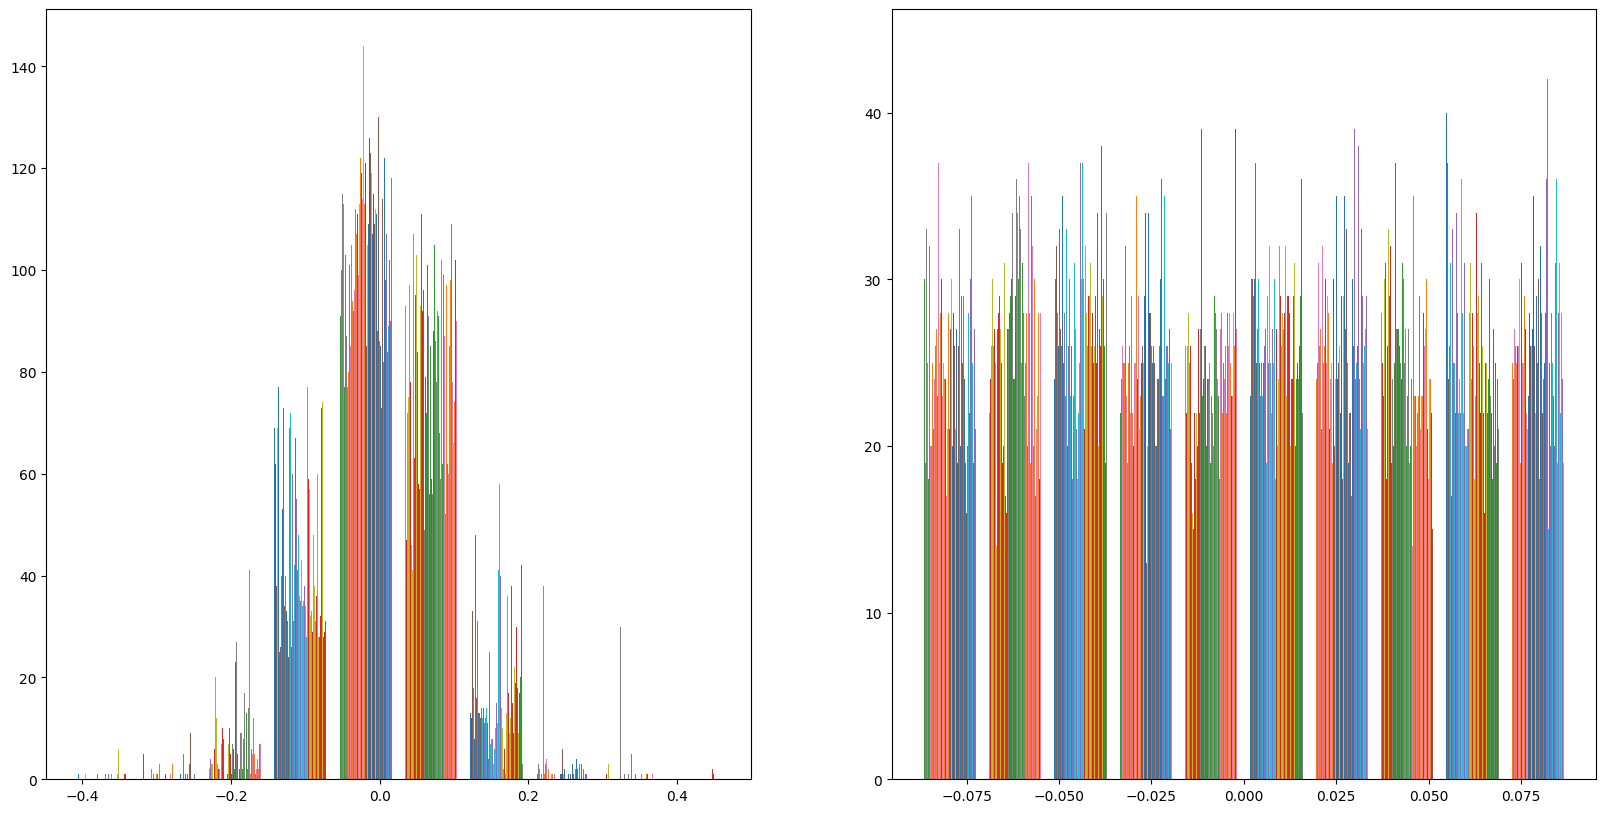

In [26]:
from matplotlib import pyplot as plt

state = model.state_dict()
w = state["decoder.production_head.production_proj.weight"].cpu().numpy()

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.hist(w)


w_random = ASTAutoencoder(
    hidden_dim=128,
    encoder_layers=3,
    max_decode_steps=100
).state_dict()["decoder.production_head.production_proj.weight"].cpu().numpy()

plt.subplot(1, 2, 2)
plt.hist(w_random)

plt.show()

In [ ]:
w

(220, 128)

In [ ]:
from dataset.grammar import get_cfg

grammar = get_cfg()

len(grammar.productions())

220

In [ ]:
w.shape

(220, 128)

In [6]:
for k in state.keys():
    print(k)


encoder.graph_encoder.node_embedding.node_type_embedding.weight
encoder.graph_encoder.node_embedding.operator_embedding.weight
encoder.graph_encoder.node_embedding.variable_embedding.weight
encoder.graph_encoder.node_embedding.value_type_embedding.weight
encoder.graph_encoder.node_embedding.int_bucket_embedding.weight
encoder.graph_encoder.node_embedding.small_constant_embedding.weight
encoder.graph_encoder.node_embedding.int_continuous_proj.weight
encoder.graph_encoder.node_embedding.int_continuous_proj.bias
encoder.graph_encoder.node_embedding.str_length_bucket_embedding.weight
encoder.graph_encoder.node_embedding.str_features_proj.weight
encoder.graph_encoder.node_embedding.str_features_proj.bias
encoder.graph_encoder.node_embedding.bool_embedding.weight
encoder.graph_encoder.node_embedding.depth_embedding.weight
encoder.graph_encoder.node_embedding.semantic_flag_embedding.weight
encoder.graph_encoder.node_embedding.output_proj.weight
encoder.graph_encoder.node_embedding.output_proj

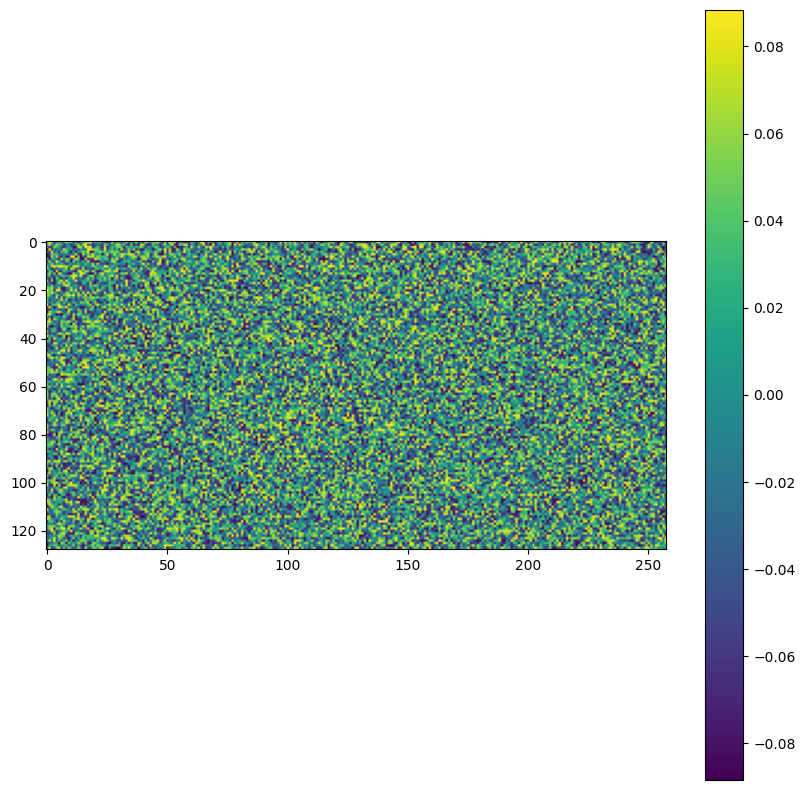

In [25]:
plt.figure(figsize=(10, 10))
plt.imshow(w_random.T)
plt.colorbar()

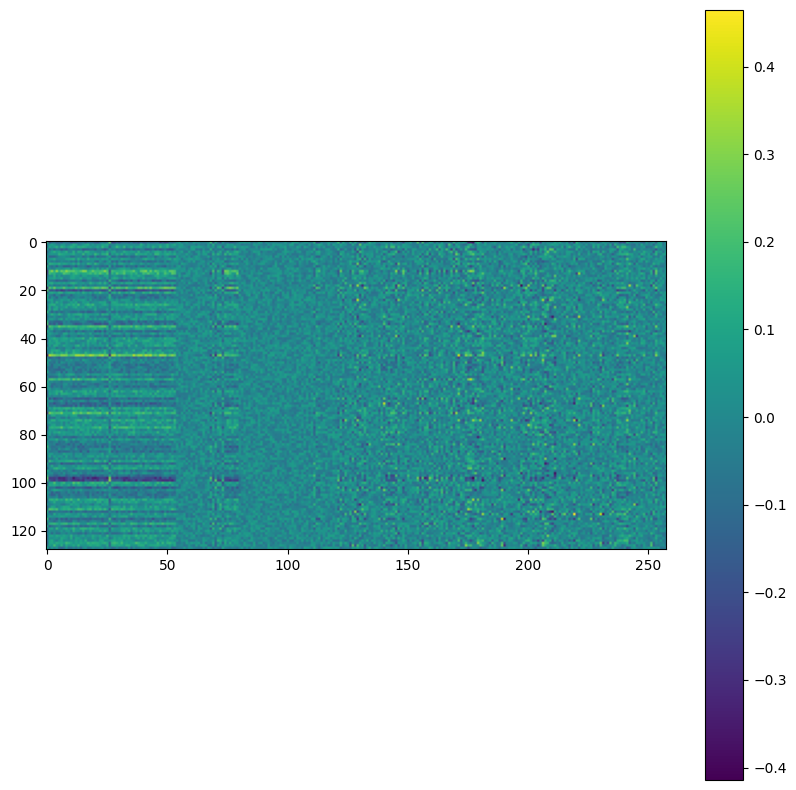

In [24]:
plt.figure(figsize=(10, 10))
plt.imshow(state["decoder.production_head.production_proj.weight"].cpu().numpy().T)
plt.colorbar()

In [ ]:
for k in checkpoint["model_state_dict"].keys():
    if "decoder" in k:
        print(k)

decoder.production_head.production_proj.weight
decoder.production_head.production_proj.bias
decoder.identifier_head.gen_proj.weight
decoder.identifier_head.gen_proj.bias
decoder.identifier_head.copy_gate.weight
decoder.identifier_head.copy_gate.bias
decoder.identifier_head.copy_attention.weight
decoder.identifier_head.copy_attention.bias
decoder.literal_head.type_proj.weight
decoder.literal_head.type_proj.bias
decoder.literal_head.int_proj.weight
decoder.literal_head.int_proj.bias
decoder.literal_head.bool_proj.weight
decoder.literal_head.bool_proj.bias
decoder.literal_head.str_proj.weight
decoder.literal_head.str_proj.bias
decoder.literal_head.str_len_proj.weight
decoder.literal_head.str_len_proj.bias
decoder.function_call_head.func_proj.weight
decoder.function_call_head.func_proj.bias
decoder.function_call_head.arg_count_proj.weight
decoder.function_call_head.arg_count_proj.bias
decoder.control_flow_head.control_proj.weight
decoder.control_flow_head.control_proj.bias
encoder_to_decod

In [32]:
model = ASTAutoencoder(
    hidden_dim=128,
    encoder_layers=3,
    max_decode_steps=100
).to(torch.device("mps"))

In [33]:
from pprint import pprint
from dataset.grammar import parse_program_with_ast

num_compiled_programs = 0
num_total = 0
for _ in range(100):
    latent = torch.randn(1, 1, 128).to(torch.device("mps"))

    result = model.decode(latent=latent, max_steps=100)
    code = result["programs"][0]
    if parse_program_with_ast(code):
        code = "✅ " + code
        num_compiled_programs += 1
    else:
        code = "❌ " + code
    num_total += 1
    print(code)

print(f"Num compiled programs: {num_compiled_programs}/{num_total}")

❌ def program (t , r , h ) :
    while (b (not f // [] // + + +
❌ def program (v , v , p , x , c ) :
    e . append ()
    if (i [not not not not not not
❌ def program (u ) :
    v , l , r = (not not not [not True * + + + +
❌ def program (z ) :
    while m [range (f . upper (not not not not not not
❌ def program (o , q , z ) :















    while + + + +
❌ def program (h ) :
    if not not not False % (e . lower () ** False / + + + +
❌ def program (f ) :
    if set (not not max ((o ** a . append () // +
❌ def program (o , e ) :
    return b - k ((not not not + + + +
❌ def program (q , o , y , t , g ) :
    for m in range (n . append () ** False % + + + + +
❌ def program (o ) :


    for _ in range (not not not not not f . append (v % + + + + +
❌ def program (n , l ) :
    if not c [- [] * [(+ + + +
❌ def program (k ) :















    for _ in range (not not not not not not not not not
❌ def program (j ) :
    for d in range (False ** [] + j [e . append () + + + + +
❌ def progr

def program (p ) :
    if not 5 // u . upper (not q [not not not not not not
